In [1]:
# 单元格 1：导入库

# 使用说明
# 运行环境：需要 pandas, matplotlib, numpy。如果没有安装，请在 Anaconda Prompt 中执行 pip install pandas matplotlib numpy。
# 路径修改：如果数据文件不在代码中的路径，请将 pd.read_csv(...) 中的路径改为实际路径。
# 内存提示：smart_log_20191231.csv 原始文件可能较大（几GB），如果内存不足，可以在 pd.read_csv 中加入 nrows=500000 先测试子集。
# 后续分析建议：
# 可以用 merged 数据绘制其他 SMART 指标（例如 r_9, r_12, r_175）的箱线图。
# 时间趋势分析：提取故障盘，按 ds 排序，画故障前 30 天的指标曲线。
# 建模：以 failure 为标签，SMART 指标为特征，使用 sklearn 做分类预测。


# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置 matplotlib 图表显示（避免中文乱码，但标签用英文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']  # Windows/Mac 备用
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 单元格 2：加载故障标签表
# 1. 加载故障标签表（只读 disk_id 和 failure 两列）
# 注意：这个文件里所有 failure 都是 1，表示故障盘。稍后合并用。
fail_tag = pd.read_csv(
    'D:/Data/学习工作/大学学习资料文件/大三下-大数据处理/大作业/数据集/dcbrain/ssd_open_data/ssd_failure_tag.csv/ssd_failure_tag.csv',
    usecols=['disk_id', 'failure']
)
print("故障标签表形状:", fail_tag.shape)
print("故障标签表中 failure=1 的数量:", fail_tag['failure'].sum())

故障标签表形状: (18387, 2)
故障标签表中 failure=1 的数量: 18387


In [5]:
# 单元格 3：加载 SMART 日志（只选关键列）
# 2. 加载 SMART 日志（只选必要列，减少内存）
# 选择的指标：disk_id（主键），ds（日期），model（型号）
# 以及几个重要的 SMART 指标：r_5, n_5, r_9, n_9, r_12, n_12, r_175, n_175
smart = pd.read_csv(
    'D:/Data/学习工作/大学学习资料文件/大三下-大数据处理/大作业/数据集/dcbrain/ssd_open_data/smart_log_20191231.csv/20191231.csv',
    usecols=['disk_id', 'ds', 'model', 'r_5', 'n_5', 'r_9', 'n_9', 'r_12', 'n_12', 'r_175', 'n_175']
)
print("SMART日志形状:", smart.shape)
print("前5行预览:")
print(smart.head())

SMART日志形状: (706182, 11)
前5行预览:
   disk_id        ds model    n_5  r_5    n_9      r_9   n_12  r_12  n_175  \
0      100  20191231    A6   96.0  0.0  100.0  38830.0  100.0  29.0  100.0   
1   100004  20191231    B1  100.0  0.0   93.0  31736.0   99.0  21.0    NaN   
2   100012  20191231    B1  100.0  0.0   92.0  37652.0   99.0   9.0    NaN   
3    10003  20191231    B1  100.0  0.0   92.0  37602.0   99.0  14.0    NaN   
4    10004  20191231    B1  100.0  0.0   92.0  37603.0   99.0  14.0    NaN   

          r_175  
0  9.881147e+11  
1           NaN  
2           NaN  
3           NaN  
4           NaN  


In [7]:
# 单元格 4：合并数据，生成 merged
# 3. 左连接：smart 为主表，用 disk_id 关联故障标签
# 未匹配上的 disk_id 说明从未故障，failure 填充 0（健康盘）
merged = smart.merge(fail_tag, on='disk_id', how='left')
merged['failure'] = merged['failure'].fillna(0).astype(int)

print("合并后总形状:", merged.shape)
print("failure 值分布（记录数）:")
print(merged['failure'].value_counts())
print("\n合并后前5行:")
print(merged.head())

合并后总形状: (710570, 12)
failure 值分布（记录数）:
failure
0    636350
1     74220
Name: count, dtype: int64

合并后前5行:
   disk_id        ds model    n_5  r_5    n_9      r_9   n_12  r_12  n_175  \
0      100  20191231    A6   96.0  0.0  100.0  38830.0  100.0  29.0  100.0   
1   100004  20191231    B1  100.0  0.0   93.0  31736.0   99.0  21.0    NaN   
2   100012  20191231    B1  100.0  0.0   92.0  37652.0   99.0   9.0    NaN   
3    10003  20191231    B1  100.0  0.0   92.0  37602.0   99.0  14.0    NaN   
4    10004  20191231    B1  100.0  0.0   92.0  37603.0   99.0  14.0    NaN   

          r_175  failure  
0  9.881147e+11        0  
1           NaN        0  
2           NaN        0  
3           NaN        0  
4           NaN        0  


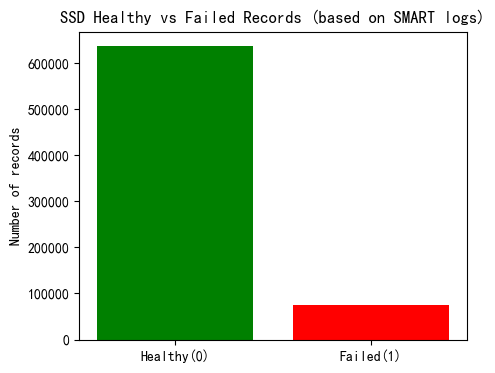

In [9]:
# 单元格 5：整体故障/健康记录数柱状图
# 4. EDA：画出健康盘 vs 故障盘的记录数量柱状图
counts = merged['failure'].value_counts()
plt.figure(figsize=(5,4))
plt.bar(['Healthy(0)', 'Failed(1)'], counts, color=['green', 'red'])
plt.title('SSD Healthy vs Failed Records (based on SMART logs)')
plt.ylabel('Number of records')
plt.savefig('figures/healthy_vs_failed_count.png', dpi=300, bbox_inches='tight')
plt.show()

各型号故障率统计:
       Total_Disks  Failure_Rate
model                           
A6            1574      0.209657
A5            3729      0.195227
A3            2520      0.194444
C2            2097      0.193133
A4            5460      0.187363
B2            6410      0.166615
B3            5147      0.165728
B1           23245      0.106216
A2           14869      0.099603
A1          117636      0.047035
C1           70733      0.026367


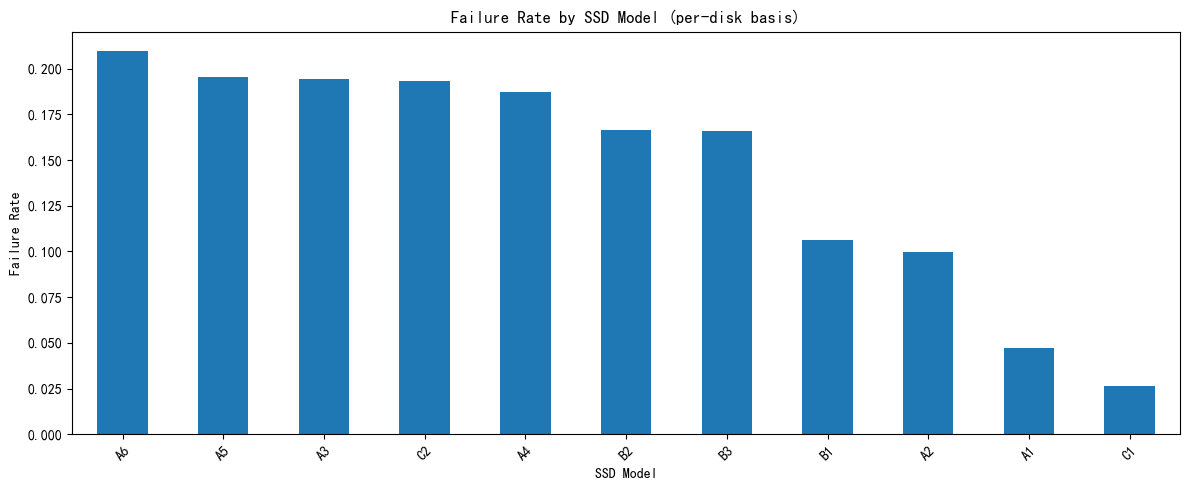

In [11]:
# 单元格 6：按型号统计故障率（去重，每块盘只计一次）
# 5. 不同 SSD 型号的故障率（按 disk_id 去重，避免同一块盘多条记录）
unique_disks = merged.drop_duplicates(subset='disk_id')
model_stats = unique_disks.groupby('model')['failure'].agg(['count', 'mean'])
model_stats.columns = ['Total_Disks', 'Failure_Rate']
model_stats = model_stats.sort_values('Failure_Rate', ascending=False)
print("各型号故障率统计:")
print(model_stats)

# 画条形图
plt.figure(figsize=(12,5))
model_stats['Failure_Rate'].plot(kind='bar')
plt.title('Failure Rate by SSD Model (per-disk basis)')
plt.xlabel('SSD Model')
plt.ylabel('Failure Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/failure_rate_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 600x400 with 0 Axes>

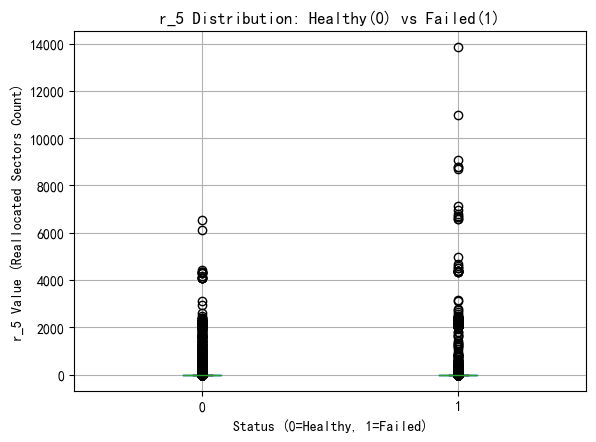

In [13]:
# 单元格 7：箱线图 - 健康盘 vs 故障盘的 r_5 分布
# 6. 关键 SMART 指标 r_5（重分配扇区数）对比
plt.figure(figsize=(6,4))
merged.boxplot(column='r_5', by='failure')
plt.title('r_5 Distribution: Healthy(0) vs Failed(1)')
plt.suptitle('')  # 去掉默认的标题
plt.xlabel('Status (0=Healthy, 1=Failed)')
plt.ylabel('r_5 Value (Reallocated Sectors Count)')
plt.savefig('figures/r5_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# 单元格 8：检查缺失值（可选，供B同学参考）
# 7. 查看各列缺失比例（帮助后续决定是否填充）
missing_pct = merged.isna().mean() * 100
print("各列缺失率（%）:")
print(missing_pct.sort_values())

各列缺失率（%）:
disk_id     0.000000
ds          0.000000
model       0.000000
failure     0.000000
n_5         0.000141
r_5         0.000141
n_9         0.000141
r_9         0.000141
n_12        0.910396
r_12        0.910396
n_175      50.786129
r_175      50.786129
dtype: float64


In [17]:
# 单元格 9：保存处理后的数据为 CSV（供B同学后续分析）
# 8. 将 merged 数据保存为新的 csv 文件，避免每次重新运行合并
merged.to_csv('merged_smart_failure.csv', index=False)
print("已保存 merged_smart_failure.csv，后续可直接读取。")

已保存 merged_smart_failure.csv，后续可直接读取。
